In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib widget

In [2]:
# constants and mesh
Nx = 10
Ny = 10
dim = Nx*Ny
Lx = 0.1 # metres
Ly = 0.1 # metres
dx = Lx/Nx
dy = Ly/Ny
t = 10 # seconds
dt = 0.01 # seconds
alpha = 23e-6 # m^2/s
beta = 23e-6 # m^2/s
A = dt*alpha/(dx**2)
B = dt*beta/(dy**2)
C = dt*(alpha*(dy**2) + beta*(dx**2))/((dx**2) * (dy**2))
C_LHS = 2*(1+C)
C_RHS = 2*(1-C)

u = np.ones([Nx, Ny])

In [3]:
from scipy.sparse import diags
main_diag = np.full(dim, C_LHS)
x_off_diag = np.full(dim - 1, -A)
y_off_diag = np.full(dim - Nx, -B)

diagonals = [main_diag, x_off_diag, x_off_diag, y_off_diag, y_off_diag]
offsets = [0, -1, 1, -Nx, Nx]
SLHS1 = diags(diagonals, offsets, shape=(dim, dim)).tocsr()
main_diag = np.full(dim, C_RHS)
diagonals = [main_diag, -x_off_diag, -x_off_diag, -y_off_diag, -y_off_diag]
SRHS1 = diags(diagonals, offsets, shape=(dim, dim)).tocsr()

In [4]:
# matrix setup

LHS = np.zeros((dim,dim))
np.fill_diagonal(LHS, C_LHS)
first_diag = np.arange(dim-1)
second_diag = np.arange(Nx, dim)
LHS[first_diag + 1, first_diag] = -A
LHS[second_diag - Nx, second_diag] = -B
LHS = (LHS + LHS.transpose()) - np.diag(LHS.diagonal())
RHS = LHS.copy()
RHS *= -1
np.fill_diagonal(RHS, C_RHS)

In [5]:
LHS==SLHS1, RHS == SRHS1

(matrix([[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True]]),
 matrix([[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True]]))

In [6]:
# RHS = np.zeros((dim, dim))
# np.fill_diagonal(RHS, C_RHS)
# first_diag = np.arange(dim-1)
# second_diag = np.arange(Nx, dim)
# RHS[first_diag + 1, first_diag] = A
# RHS[second_diag - Nx, second_diag] = B
# RHS = (RHS + RHS.transpose()) - np.diag(RHS.diagonal())

In [7]:
# t = 1
# flat_u = u.flatten()
# solutions_np = []
# while t > 0:
#     b = RHS@flat_u
#     sol = sp.sparse.linalg.spsolve(LHS, b)
#     t -= dt
#     solutions_np.append(sol)
#     flat_u = sol

In [8]:
for i in range (-5, 5):
    for j in range(-5, 5):
        u[50+i,50+j] = 100
t = 1
flat_u = u.flatten()
solutions_sparse = [flat_u]
SLHS = sp.sparse.csr_array(LHS)
SRHS = sp.sparse.csr_array(RHS)
while t > 0:
    b = SRHS@flat_u
    b = sp.sparse.csr_array(b)
    sol = sp.sparse.linalg.spsolve(SLHS, b)
    t -= dt
    solutions_sparse.append(sol)
    flat_u = sol

IndexError: index 45 is out of bounds for axis 0 with size 10

In [ ]:
solutions = [solution.reshape(100,100) for solution in solutions_sparse]

In [ ]:
solutions[950]

IndexError: list index out of range

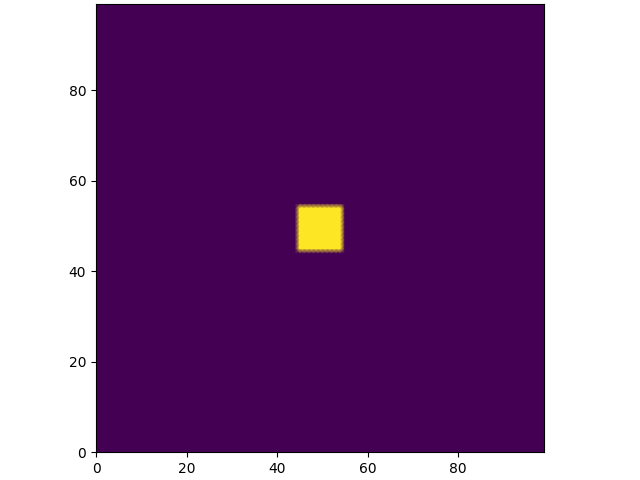

No such comm: 26bf60862c0a4e91b158377905173511
No such comm: 26bf60862c0a4e91b158377905173511
No such comm: 26bf60862c0a4e91b158377905173511
No such comm: 26bf60862c0a4e91b158377905173511
No such comm: 26bf60862c0a4e91b158377905173511
No such comm: 26bf60862c0a4e91b158377905173511


In [ ]:
Nx = Ny = 100

# plt.imshow(solutions_sparse[0].reshape(100,100))
fig, ax = plt.subplots(layout='constrained')
x = np.arange(Nx)
y = np.arange(Ny)
mesh = ax.pcolormesh(x, y, solutions[0], shading='gouraud')
ax.set_aspect('equal')

def update(frame):
    mesh.set_array(solutions[frame].ravel())
    return [mesh]

anim = FuncAnimation(fig=fig, func=update, frames=len(solutions), interval=10, repeat=True,blit=False)
    
plt.show()

In [ ]:
plt.close('all')